In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import chaospy as cp

## Parameters

In [2]:
ntot = 1.7e20  # total density
Vp = 150 
#cross sections at 14 keV
sigmavDT = 2.4e-22
sigmavDDn = 1.2e-24
sigmavDDp = 1.2e-24
TBRDT = 1.15
TBRDD = 0.9  # TBR for D-D plasma
lambda_T = 1.78e-9  # decay constant for tritium
tau_ofc = 1*3600*24 # 1 day
tau_ifc = 3600*4 # 4 h
tau_p_T = 1

tritium_mass = 3.016049268e-3 / 6.022e23  # kg per tritium atom (3.016 u -> kg)

## Model functions

In [3]:
def tritium_inventory_odes(t,y):
    
    N_ofc, N_ifc, N_st, nT = y
    
    def f_T_inj(t,N_st,nT):
        if N_st > nT*Vp:
            return (0.9999)
        else:
            return 0.9999 # constant injection rate, can be modified to a function of time or state variables
    
    dN_ofc_dt = TBRDT*(ntot-nT)*nT*sigmavDT*Vp + TBRDD*0.5*(ntot-nT)**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
    dN_stor_dt = (N_ifc / tau_ifc - lambda_T * N_st )*(1 - f_T_inj(t,N_st,nT))
    dnT_dt = f_T_inj(t,N_st,nT)/Vp*((N_ifc / tau_ifc - lambda_T * N_st )) + 0.5*(ntot-nT)**2*sigmavDDp - nT/tau_p_T - (ntot-nT)*nT*sigmavDT

    return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]


y0 = [0, 0, 0, 0]  # Initial conditions: [I_ofc, I_ifc, I_st, n_T]

# Time span
years_to_seconds = 365 * 24 * 3600
t_span = (0, 1000*years_to_seconds)

t_eval = np.linspace(*t_span, 10)

def DT_reached(t, y): 
    # stop when 50% D - 50% T is reached (when nT/ntot = 0.5)
    return y[3] - (0.5 * ntot)
    
# stop whe  DT reached
DT_reached.terminal = True
# Solve ODE
# sol = solve_ivp(tritium_inventory_odes, t_span, y0,method = 'BDF', events = DT_reached, dense_output=True)


def N_T_in_rate(N_st, target_rate=100e20, min_storage=0.01/tritium_mass):
    """
    Adaptive tritium injection rate that prevents storage depletion
    
    Parameters:
    - N_st: current storage inventory [particles]
    - target_rate: desired injection rate [particles/s]
    - min_storage: minimum storage to maintain [particles]
    
    Returns:
    - actual injection rate [particles/s]
    """
    if N_st <= min_storage:
        return 0.0  # No injection if storage is too low
    
    # Available storage above minimum threshold
    available_storage = N_st - min_storage
    
    # Limit injection rate to prevent depletion
    max_safe_rate = 0.5 * available_storage
    
    # Return the minimum of target rate and safe rate
    return min(target_rate, max_safe_rate)

def tritium_inventory_odes1(t,y):
    
    N_ofc, N_ifc, N_st, nT = y
    # Calculate adaptive injection rate
    injection_rate = N_T_in_rate(N_st)
    
    
    dN_ofc_dt = TBRDT*(ntot-nT)*nT*sigmavDT*Vp + TBRDD*0.5*(ntot-nT)**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
    dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - injection_rate
    dnT_dt = injection_rate/Vp + 0.5*(ntot-nT)**2*sigmavDDp - nT/tau_p_T - (ntot-nT)*nT*sigmavDT

    return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]


y0 = [0, 0, 0, 0]  # Initial conditions: [I_ofc, I_ifc, I_st, n_T]

# Time span
years_to_seconds = 365 * 24 * 3600
t_span = (0, 10*years_to_seconds)

t_eval = np.linspace(*t_span, 10)

def DT_reached(t, y): 
    # stop when 50% D - 50% T is reached (when nT/ntot = 0.5)
    return y[3] - (0.5 * ntot)
def NEGATIVE(t, y):
    # stop when y[0] or y[1] or y[2] or y[3] is negative
    return min(y[0]+1e-10, y[1]+1e-10, y[2]+1e-10, y[3]+1e-10)

    
# stop whe  DT reached
DT_reached.terminal = True
NEGATIVE.terminal = True
# Solve ODE
sol1 = solve_ivp(tritium_inventory_odes1, t_span, y0,method = 'LSODA', events = [DT_reached, NEGATIVE], dense_output=True)


Check that the code is working as intended

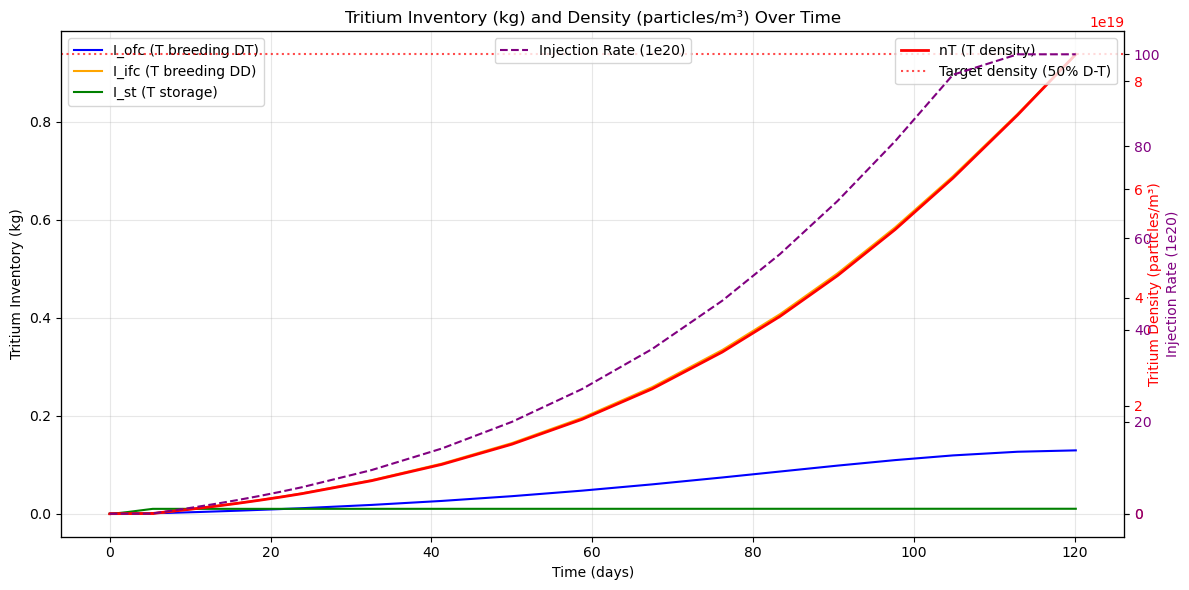

Final tritium inventory: 1.02e-02 kg
Final tritium density: 8.50e+19 particles/m³
Final injection rate: 5.0083847027565595e-05 kg/s
[array([10381354.11919489]), array([], dtype=float64)]
Total time to reach 50% D-T: 120.15 days


In [4]:
# Constants for unit conversion

# plotting the results with dual y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis: Inventory in kg
ax1.plot(sol1.t/(24*3600), sol1.y[0] * tritium_mass, label='I_ofc (T breeding DT)', color='blue')
ax1.plot(sol1.t/(24*3600), sol1.y[1] * tritium_mass, label='I_ifc (T breeding DD)', color='orange')
ax1.plot(sol1.t/(24*3600), sol1.y[2] * tritium_mass, label='I_st (T storage)', color='green')


ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Tritium Inventory (kg)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')


# Right y-axis: Tritium density in particles/m³
ax2 = ax1.twinx()
ax2.plot(sol1.t/(24*3600), sol1.y[3], label='nT (T density)', color='red', linewidth=2)
ax2.set_ylabel('Tritium Density (particles/m³)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Target density line
ax2.axhline(y=0.5 * ntot, color='red', linestyle=':', alpha=0.7, 
           label='Target density (50% D-T)')
ax2.legend(loc='upper right')

# ax3 injection rate
ax3 = ax1.twinx()
# plot injection rate in kg/s
ax3.plot(sol1.t/(24*3600), [(N_T_in_rate(value)/1e20 ) for value in sol1.y[2]], label='Injection Rate (1e20)', color='purple', linestyle='--')
ax3.set_ylabel('Injection Rate (1e20)', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')
ax3.legend(loc='upper center')

plt.title('Tritium Inventory (kg) and Density (particles/m³) Over Time')
plt.tight_layout()
#plt.xlim(0, 0.3*years_to_seconds)  # Limit x-axis to 10 years
plt.show()

print(f"Final tritium inventory: {sol1.y[2][-1] * tritium_mass:.2e} kg")
print(f"Final tritium density: {sol1.y[3][-1]:.2e} particles/m³")
print("Final injection rate:", N_T_in_rate(sol1.y[2][-1])*tritium_mass, "kg/s")
print(sol1.t_events)
print(f"Total time to reach 50% D-T: {sol1.t_events[0][0]/(24*3600):.2f} days")


In [5]:
deviation = 0.2

# Check parameter values first
print("Parameter values:")
print(f"ntot: {ntot}")
print(f"Vp: {Vp}")
print(f"sigmavDT: {sigmavDT}")
print(f"sigmavDDn: {sigmavDDn}")
print(f"sigmavDDp: {sigmavDDp}")
print(f"TBRDT: {TBRDT}")
print(f"TBRDD: {TBRDD}")
print(f"lambda_T: {lambda_T}")
print(f"tau_ofc: {tau_ofc}")
print(f"tau_ifc: {tau_ifc}")
print(f"tau_p_T: {tau_p_T}")

# For uniform distributions, we need lower < upper
# Using (1-deviation)*value as lower and (1+deviation)*value as upper
distr_params = {
    "ntot": cp.Normal(ntot, deviation * ntot),
    "Vp": cp.Normal(Vp, deviation * Vp),
    "sigmavDT": cp.Normal(sigmavDT, deviation * sigmavDT),
    "sigmavDDn": cp.Normal(sigmavDDn, deviation * sigmavDDn),
    "sigmavDDp": cp.Normal(sigmavDDp, deviation * sigmavDDp),
    "TBRDT": cp.Normal(TBRDT, deviation * TBRDT),
    "TBRDD": cp.Normal(TBRDD, deviation * TBRDD),
    "lambda_T": cp.Normal(lambda_T, deviation * lambda_T),
    "tau_ofc": cp.Normal(tau_ofc, deviation * tau_ofc),
    "tau_ifc": cp.Normal(tau_ifc, deviation * tau_ifc),
    "tau_p_T": cp.Normal(tau_p_T, deviation * tau_p_T)
}

# Check bounds
# print("\nDistribution bounds:")
# for name, dist in distr_params.items():
#     print(f"{name}: [{dist.lower[0]:.2e}, {dist.upper[0]:.2e}]")

joint_distribution = cp.J(*distr_params.values())

number_of_samples = 1000
samples = joint_distribution.sample(number_of_samples, rule="L")
print(f"\nSamples shape: {samples.shape}")
print("Sample generation successful!")

Parameter values:
ntot: 1.7e+20
Vp: 150
sigmavDT: 2.4e-22
sigmavDDn: 1.2e-24
sigmavDDp: 1.2e-24
TBRDT: 1.15
TBRDD: 0.9
lambda_T: 1.78e-09
tau_ofc: 86400
tau_ifc: 14400
tau_p_T: 1

Samples shape: (11, 1000)
Sample generation successful!


In [6]:
def solve_for_sample(sample_params):
    """
    Solve the ODE system for a given parameter sample
    
    Parameters:
    sample_params: array of parameter values in the order of distr_params
    
    Returns:
    dict with solution results or None if solution failed
    """
    # Extract parameters from sample
    (ntot_s, Vp_s, sigmavDT_s, sigmavDDn_s, sigmavDDp_s, 
     TBRDT_s, TBRDD_s, lambda_T_s, tau_ofc_s, tau_ifc_s, tau_p_T_s) = sample_params
    
    # Define ODE system with sampled parameters
    def tritium_inventory_odes_sampled(t, y):
        N_ofc, N_ifc, N_st, nT = y
        
        # Calculate adaptive injection rate
        injection_rate = N_T_in_rate(N_st)
        
        dN_ofc_dt = TBRDT_s*(ntot_s-nT)*nT*sigmavDT_s*Vp_s + TBRDD_s*0.5*(ntot_s-nT)**2*sigmavDDn_s*Vp_s - N_ofc / tau_ofc_s - N_ofc*lambda_T_s
        dN_ifc_dt = N_ofc / tau_ofc_s - N_ifc / tau_ifc_s - lambda_T_s * N_ifc + nT / tau_p_T_s * Vp_s
        dN_stor_dt = N_ifc / tau_ifc_s - lambda_T_s * N_st - injection_rate
        dnT_dt = injection_rate/Vp_s + 0.5*(ntot_s-nT)**2*sigmavDDp_s - nT/tau_p_T_s - (ntot_s-nT)*nT*sigmavDT_s

        return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]
    
    # Define events with sampled parameters
    def DT_reached_sampled(t, y): 
        return y[3] - (0.5 * ntot_s)
    
    def NEGATIVE_sampled(t, y):
        return min(y[0]+1e-10, y[1]+1e-10, y[2]+1e-10, y[3]+1e-10)
    
    DT_reached_sampled.terminal = True
    NEGATIVE_sampled.terminal = True
    
    # Initial conditions and time span
    y0 = [0, 0, 0, 0]
    years_to_seconds = 365 * 24 * 3600
    t_span = (0, 10*years_to_seconds)
    
    try:
        # Solve the ODE
        sol = solve_ivp(tritium_inventory_odes_sampled, t_span, y0, 
                       method='LSODA', events=[DT_reached_sampled, NEGATIVE_sampled], 
                       dense_output=True, rtol=1e-8, atol=1e-10)
        
        if sol.success:
            # Extract relevant metrics
            startup_time = None
            if len(sol.t_events[0]) > 0:  # DT_reached event occurred
                startup_time = sol.t_events[0][0] / (24*3600)  # Convert to days
            
            final_storage = sol.y[2][-1] * tritium_mass  # kg
            final_density = sol.y[3][-1]  # particles/m³
            
            return {
                'startup_time': startup_time,
                'final_storage': final_storage,
                'final_density': final_density,
                'success': True,
                'solution': sol
            }
        else:
            return {'success': False, 'message': sol.message}
            
    except Exception as e:
        return {'success': False, 'message': str(e)}

# Test with a single sample first
print("Testing with first sample...")
test_result = solve_for_sample(samples[:, 0])
print(f"Test result: {test_result}")

Testing with first sample...
Test result: {'startup_time': None, 'final_storage': np.float64(0.010010686820523), 'final_density': np.float64(7.84504768503567e+18), 'success': True, 'solution':   message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.135e-24 ...  3.055e+08  3.154e+08]
        y: [[ 0.000e+00  1.000e-06 ...  1.661e+24  1.661e+24]
            [ 0.000e+00  1.825e-30 ...  1.882e+25  1.882e+25]
            [ 0.000e+00  0.000e+00 ...  1.999e+24  1.999e+24]
            [ 0.000e+00  1.210e-08 ...  7.845e+18  7.845e+18]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f1e008d8b90>
 t_events: [array([], dtype=float64), array([], dtype=float64)]
 y_events: [array([], dtype=float64), array([], dtype=float64)]
     nfev: 2305
     njev: 177
      nlu: 177}


In [7]:
# Run ODE analysis for all 10,000 samples and calculate Sobol indices
print(f"Running ODE analysis for {samples.shape[1]} samples...")
print("This will take several minutes...")

results = []
successful_runs = 0
failed_runs = 0

# Progress tracking
import time
start_time = time.time()

for i in range(samples.shape[1]):
    if i % (number_of_samples/10) == 0:  # Progress update
        elapsed = time.time() - start_time
        if i > 0:
            estimated_remaining = (elapsed / i) * (samples.shape[1] - i)
            print(f"Processed {i}/{samples.shape[1]} samples ({i/samples.shape[1]*100:.1f}%) - "
                  f"Elapsed: {elapsed:.1f}s - "
                  f"ETA: {estimated_remaining:.1f}s - "
                  f"Success rate: {successful_runs/i*100:.1f}%")
        else:
            print(f"Starting analysis...")
    
    result = solve_for_sample(samples[:, i])
    results.append(result)
    
    if result['success']:
        successful_runs += 1
    else:
        failed_runs += 1

total_time = time.time() - start_time
print(f"\nODE analysis completed!")
print(f"Total time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"Average time per sample: {total_time/samples.shape[1]:.3f} seconds")
print(f"Successful runs: {successful_runs}/{len(results)} ({successful_runs/len(results)*100:.1f}%)")
print(f"Failed runs: {failed_runs}/{len(results)} ({failed_runs/len(results)*100:.1f}%)")

print(f"\nProceeding to Sobol analysis...")

Running ODE analysis for 1000 samples...
This will take several minutes...
Starting analysis...
Processed 100/1000 samples (10.0%) - Elapsed: 2.9s - ETA: 26.0s - Success rate: 100.0%
Processed 200/1000 samples (20.0%) - Elapsed: 5.7s - ETA: 22.9s - Success rate: 100.0%
Processed 300/1000 samples (30.0%) - Elapsed: 8.3s - ETA: 19.4s - Success rate: 100.0%
Processed 400/1000 samples (40.0%) - Elapsed: 13.1s - ETA: 19.7s - Success rate: 100.0%
Processed 500/1000 samples (50.0%) - Elapsed: 19.1s - ETA: 19.1s - Success rate: 100.0%
Processed 600/1000 samples (60.0%) - Elapsed: 23.7s - ETA: 15.8s - Success rate: 100.0%
Processed 700/1000 samples (70.0%) - Elapsed: 29.4s - ETA: 12.6s - Success rate: 100.0%
Processed 800/1000 samples (80.0%) - Elapsed: 36.8s - ETA: 9.2s - Success rate: 100.0%
Processed 900/1000 samples (90.0%) - Elapsed: 41.2s - ETA: 4.6s - Success rate: 100.0%

ODE analysis completed!
Total time: 45.8 seconds (0.8 minutes)
Average time per sample: 0.046 seconds
Successful run

## Sobol Sensitivity Analysis and Polynomial Chaos Expansion (PCE)

In [8]:
def simple_sobol_analysis(samples, outputs, parameter_names, polynomial_order=2):
    """
    Simple Sobol analysis using ChaosPy PCE with existing joint distribution
    Returns first-order, total-order Sobol indices and variance
    """
    # Filter out NaN values
    valid_mask = ~np.isnan(outputs)
    valid_samples = samples[:, valid_mask]
    valid_outputs = outputs[valid_mask]
           
    try:
        # Use the existing joint_distribution from the global scope
        # Create polynomial expansion and fit PCE model
        polynomial_expansion = cp.generate_expansion(polynomial_order, joint_distribution)
        pce_model = cp.fit_regression(polynomial_expansion, valid_samples, valid_outputs)
        
        # Calculate Sobol indices
        sobol_first = cp.Sens_m(pce_model, joint_distribution)
        sobol_total = cp.Sens_t(pce_model, joint_distribution)
        
        # Calculate variance
        variance = cp.Var(pce_model, joint_distribution)
        
        return {
            'first_order': dict(zip(parameter_names, sobol_first)),
            'total_order': dict(zip(parameter_names, sobol_total)),
            'variance': variance,
            'n_samples': len(valid_outputs)
        }
        
    except Exception as e:
        return None

print("Simple Sobol analysis function defined!")

Simple Sobol analysis function defined!


In [9]:
# Simple Sobol analysis for all outputs
parameter_names = list(distr_params.keys())
n_samples = len(results)

# Initialize output arrays
startup_time_array = np.full(n_samples, np.nan)
final_storage_array = np.full(n_samples, np.nan)
final_density_array = np.full(n_samples, np.nan)

# Fill arrays with results
for i, result in enumerate(results):
    if result['success']:
        startup_time_array[i] = result['startup_time'] if result['startup_time'] is not None else np.nan
        final_storage_array[i] = result['final_storage']
        final_density_array[i] = result['final_density']

analysis_samples = samples[:, :n_samples]

print(f"Analyzing {n_samples} samples...")
print(f"Valid startup times: {np.sum(~np.isnan(startup_time_array))}")
print(f"Valid final storage: {np.sum(~np.isnan(final_storage_array))}")
print(f"Valid final density: {np.sum(~np.isnan(final_density_array))}")

# Analyze each output
outputs = {
    'startup_time': startup_time_array,
    'final_storage': final_storage_array, 
    'final_density': final_density_array
}

sobol_results = {}

for output_name, output_array in outputs.items():
    print(f"\n{'='*50}")
    print(f"SOBOL ANALYSIS: {output_name.upper()}")
    print('='*50)
    
    result = simple_sobol_analysis(analysis_samples, output_array, parameter_names)
    
    if result:
        sobol_results[output_name] = result
        
        print(f"Samples analyzed: {result['n_samples']}")
        print(f"Variance: {result['variance']:.4e}")
        
        print(f"\nFirst-order Sobol indices:")
        for param, index in sorted(result['first_order'].items(), key=lambda x: x[1], reverse=True):
            print(f"  {param:<12}: {index:.4f}")
        
        print(f"\nTotal-order Sobol indices:")
        for param, index in sorted(result['total_order'].items(), key=lambda x: x[1], reverse=True):
            print(f"  {param:<12}: {index:.4f}")
    else:
        print("Analysis failed")

print(f"\nCompleted Sobol analysis for {len(sobol_results)} outputs!")

Analyzing 1000 samples...
Valid startup times: 182
Valid final storage: 1000
Valid final density: 1000

SOBOL ANALYSIS: STARTUP_TIME
Samples analyzed: 182
Variance: 4.4845e+03

First-order Sobol indices:
  ntot        : 1.0000
  tau_ofc     : 0.0000
  tau_ifc     : 0.0000
  TBRDD       : 0.0000
  tau_p_T     : 0.0000
  Vp          : 0.0000
  TBRDT       : 0.0000
  lambda_T    : 0.0000
  sigmavDT    : 0.0000
  sigmavDDn   : 0.0000
  sigmavDDp   : 0.0000

Total-order Sobol indices:
  ntot        : 1.0000
  Vp          : 0.0000
  sigmavDT    : 0.0000
  sigmavDDn   : 0.0000
  sigmavDDp   : 0.0000
  TBRDT       : 0.0000
  TBRDD       : 0.0000
  lambda_T    : 0.0000
  tau_ofc     : 0.0000
  tau_ifc     : 0.0000
  tau_p_T     : 0.0000

SOBOL ANALYSIS: FINAL_STORAGE
Samples analyzed: 1000
Variance: 8.5217e-01

First-order Sobol indices:
  ntot        : 1.0000
  tau_ofc     : 0.0000
  tau_ifc     : 0.0000
  tau_p_T     : 0.0000
  Vp          : 0.0000
  TBRDD       : 0.0000
  TBRDT       : 0.000

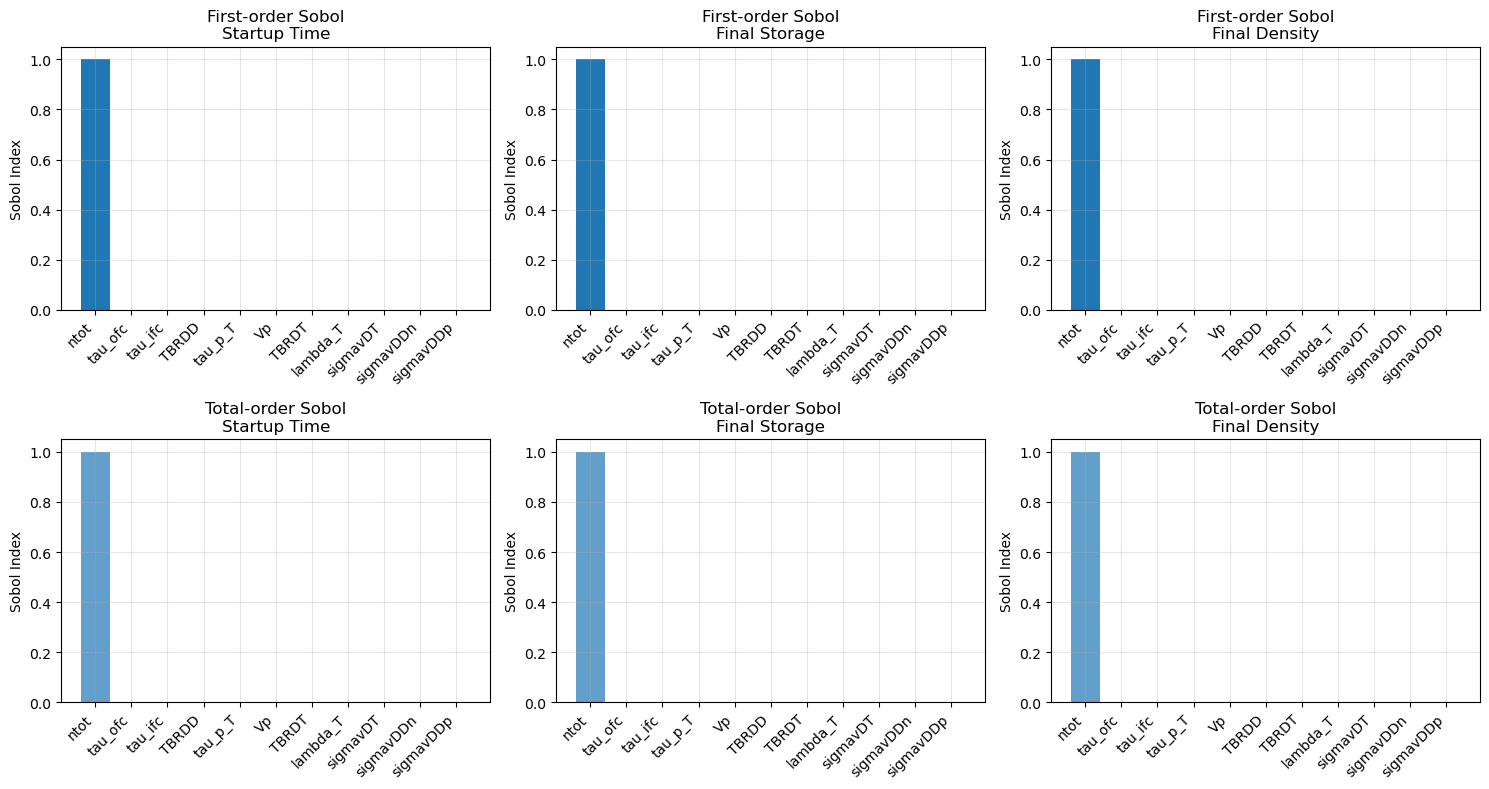


SOBOL INDICES SUMMARY

Startup Time:
Variance: 4.4845e+03
Samples: 182
Top 3 parameters (first-order):
  ntot: 1.0000
  tau_ofc: 0.0000
  tau_ifc: 0.0000

Final Storage:
Variance: 8.5217e-01
Samples: 1000
Top 3 parameters (first-order):
  ntot: 1.0000
  tau_ofc: 0.0000
  tau_ifc: 0.0000

Final Density:
Variance: 7.9384e+36
Samples: 1000
Top 3 parameters (first-order):
  ntot: 1.0000
  tau_ofc: 0.0000
  tau_ifc: 0.0000


In [10]:
# Simple visualization of Sobol indices
def plot_sobol_indices(sobol_results):
    """Simple bar plots for Sobol indices"""
    n_outputs = len(sobol_results)
    if n_outputs == 0:
        print("No results to plot")
        return
    
    fig, axes = plt.subplots(2, n_outputs, figsize=(5*n_outputs, 8))
    if n_outputs == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (output_name, results) in enumerate(sobol_results.items()):
        # First-order indices
        first_order = results['first_order']
        params = list(first_order.keys())
        values_first = list(first_order.values())
        
        # Sort by values
        sorted_pairs = sorted(zip(params, values_first), key=lambda x: x[1], reverse=True)
        params_sorted, values_first_sorted = zip(*sorted_pairs)
        
        axes[0, idx].bar(range(len(params_sorted)), values_first_sorted)
        axes[0, idx].set_title(f'First-order Sobol\n{output_name.replace("_", " ").title()}')
        axes[0, idx].set_ylabel('Sobol Index')
        axes[0, idx].set_xticks(range(len(params_sorted)))
        axes[0, idx].set_xticklabels(params_sorted, rotation=45, ha='right')
        axes[0, idx].grid(True, alpha=0.3)
        
        # Total-order indices
        total_order = results['total_order']
        values_total = [total_order[p] for p in params_sorted]
        
        axes[1, idx].bar(range(len(params_sorted)), values_total, alpha=0.7)
        axes[1, idx].set_title(f'Total-order Sobol\n{output_name.replace("_", " ").title()}')
        axes[1, idx].set_ylabel('Sobol Index')
        axes[1, idx].set_xticks(range(len(params_sorted)))
        axes[1, idx].set_xticklabels(params_sorted, rotation=45, ha='right')
        axes[1, idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot results
if sobol_results:
    plot_sobol_indices(sobol_results)
    
    # Summary table
    print("\nSOBOL INDICES SUMMARY")
    print("="*60)
    for output_name, results in sobol_results.items():
        print(f"\n{output_name.replace('_', ' ').title()}:")
        print(f"Variance: {results['variance']:.4e}")
        print(f"Samples: {results['n_samples']}")
        
        # Top 3 most influential parameters
        first_order = results['first_order']
        sorted_params = sorted(first_order.items(), key=lambda x: x[1], reverse=True)[:3]
        print("Top 3 parameters (first-order):")
        for param, value in sorted_params:
            print(f"  {param}: {value:.4f}")
else:
    print("No Sobol results to display")